# Combined notebook

## Contents

- [0 Setup And Intro](#0-setup-and-intro)
- [1_Core Qiskit 2.x workflow](#1_core-qiskit-2x-workflow)
- [2_VQE(+SQD) tutorial](#2_vqesqd-tutorial)
- [Advanced-1. Exploring Precalculated Hamiltonians](#advanced-1-exploring-precalculated-hamiltonians)
- [Advanced-2. Scalable Subspace Hamiltonian Generation from Pauli Terms and Samples](#advanced-2-scalable-subspace-hamiltonian-generation-from-pauli-terms-and-samples)

In [36]:
# Colab setup
from pathlib import Path
from urllib.request import urlretrieve
import sys

DOWNLOAD_DIR = Path(".")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

def _download(url: str, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {url} -> {dst}')
    urlretrieve(url, dst)

resolved_download_dir = str(DOWNLOAD_DIR.resolve())
if resolved_download_dir not in sys.path:
    sys.path.insert(0, resolved_download_dir)

_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/utils.py", Path("utils.py"))
_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/linear_h_chains_jw.json", Path("linear_h_chains_jw.json"))
_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/requirements.txt", Path("requirements.txt"))


# 0 Setup And Intro
<a id="0-setup-and-intro"></a>

_Source: `0_setup-and-intro.ipynb`_

## Installation

In [37]:
!pip install -r requirements.txt


-------------

## Save IBM Account
![IQP_login.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/IQP_login.png)
1. Login [IBM Quantum Platform](https://quantum.cloud.ibm.com/).
2. Create and copy API Key.
3. Assign the key to `api_token` variable in the next cell
4. Go to [Compute Resource tap](https://quantum.cloud.ibm.com/computers) and check the available backends.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

api_token = "Your IBM Quantum API token here"  # Replace with your actual API token

QiskitRuntimeService.save_account(
    token=api_token,
    overwrite=True
)

backend_name = "ibm_torino"

----------

# 1_Core Qiskit 2.x workflow
<a id="1_core-qiskit-2x-workflow"></a>

_Source: `1_qiskit_2x_core_workflow.ipynb`_

This chapter gives a compact tour of the basic Qiskit 2.x workflow:

1. create a circuit,
2. run a primitive,
3. transpile when needed,
4. define an observable,
5. estimate a quantity of interest (*Observable*),
6. and understand how execution modes are chosen in Qiskit Runtime.

## 1-1. Overview of the Workflow

A typical Qiskit 2.x workflow is built from a few standard Qiskit objects.

- A **circuit** prepares a quantum state or computation.
- A **primitive** executes a specific task.
  - **Sampler** returns sampled measurement data.
  - **Estimator** returns expectation values of observables.
- **Transpilation** prepares a circuit for a target execution environment.
- An **observable** specifies what physical quantity we want to evaluate.
- A **mode** determines how Runtime jobs are scheduled on IBM Quantum resources.

Those are mapped to Qiskit pattern:
![qiskit_pattern.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/qiskit_pattern.png)

### Check the installed Qiskit version

In [39]:
import qiskit
qiskit.__version__  # should be > 2.0

'2.3.0'


--------

## 1-2. Execution with primitives: a first `Sampler` example

We begin with the most direct replacement for “run a circuit and get outcomes”:
the **Sampler** primitive.

In the next cell, we create a **two-qubit Bell-state circuit**, measure all qubits, and send the circuit to `StatevectorSampler`.
Since this is a statevector-based local primitive, the example is easy to inspect and does not require a real backend.


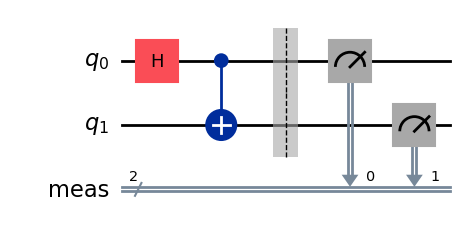

In [40]:
from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

# 1. Build a quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

qc.draw("mpl")


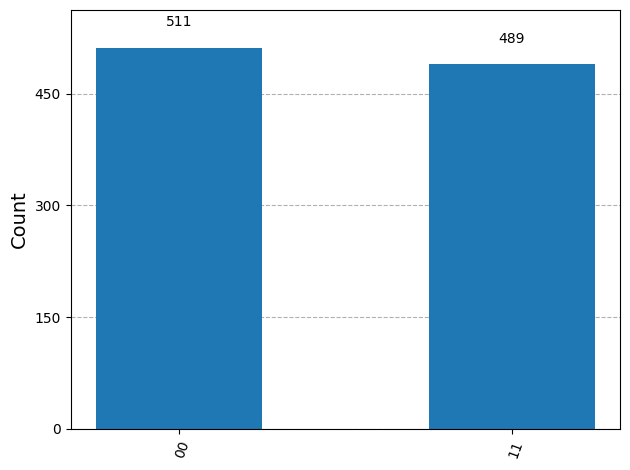

In [41]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1000)

result = job.result()
plot_histogram(result[0].data.meas.get_counts())

This is the most basic workflow (Qiskit pattern):

1. build a circuit,
2. (skipped in the emulator example here) map the circuit to a real backend, (Transpilation)
3. run a sampler (primitive),
4. inspect the returned measurement data.

For this Bell-state circuit, the dominant outcomes should be `00` and `11`.


### Exercise 1

Modify the example so that it prepares a **3-qubit GHZ state** and run it with the sampler.

Suggested steps:

1. create a 3-qubit circuit,
2. apply `H` to qubit 0,
3. apply two `CX` gates to spread the entanglement (`cx(0, 1)` and `cx(1, 2)`).
4. measure all qubits,
5. run the circuit with `StatevectorSampler`.

Which bitstrings should dominate the result?


In [42]:
# Your code here



Answer

```python
qc_ex = QuantumCircuit(3)
qc_ex.h(0)
qc_ex.cx(0,1)
qc_ex.cx(1,2)
qc_ex.measure_all()
qc_ex.draw("mpl")

job_ex = sampler.run([qc_ex], shots=1000)
result_ex = job_ex.result()
plot_histogram(result_ex[0].data.meas.get_counts())
```


--------

## 1-3. Hardware-aware transpilation with a preset pass manager

Qiskit circuits are usually written at an **abstract level**:
we describe what computation we want, not yet how a specific device must realize it.

Before execution on hardware, the circuit must be rewritten into a form that respects
- the backend's native gate set,
- connectivity constraints, and 
- optimization opportunities.
  
This is the role of the **transpiler**.

First, we load the target backend in the next cell.
Visit [https://quantum.cloud.ibm.com/computers](https://quantum.cloud.ibm.com/computers) for available backends.


In [43]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
# This may take a few seconds as it fetches the latest backend information.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
# Or by name:
backend = service.backend(backend_name)

qiskit_runtime_service.__init__:WARNING:2026-03-30 02:19:04,451: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-30 02:19:04,453: Using instance: Solutions Notebooks premium fleet, plan: premium


Qiskit 2.x encourages users to start from a built-in preset workflow through
`generate_preset_pass_manager(...)`, rather than manually assembling long pass pipelines for common use cases.
In the next cell, we show a basic transpilation.

Circuit before transpilation:
Depth =  3


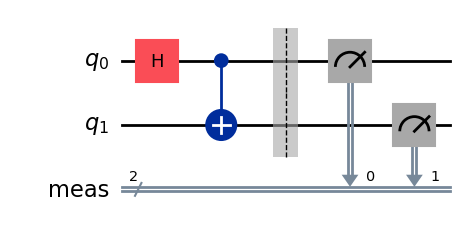

In [44]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc)

print("Circuit before transpilation:")
print("Depth = ", qc.depth())
qc.draw("mpl")

Circuit after transpilation:
Depth =  7


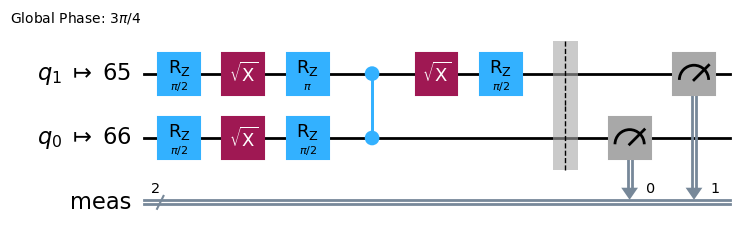

In [45]:
print("Circuit after transpilation:")
print("Depth = ", transpiled_circuit.depth())
transpiled_circuit.draw("mpl")

The circuit you write (`qc`) is not necessarily the circuit that will be executed.

A preset pass manager convert the circuit so that matches to the backend.
The passes include:
- layout selection,
- routing on limited connectivity,
- basis-gate translation,
- and circuit optimization.


### Exercise 2

For a given deep random circuit, try several optimization levels and compare the transpiled circuits.

Suggested steps:

1. generate pass managers with optimization levels `0`, `1`, `2`, and `3`,
2. run each pass manager on the same circuit,
3. compare the resulting circuit depths.

Which optimization level gives the shallowest circuit for this example?
Does the answer always have to be the same for every circuit?


Depth of the original circuit: 101


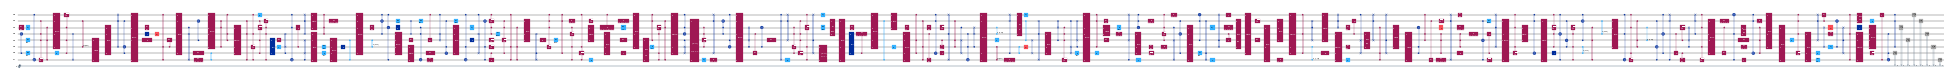

In [46]:
from qiskit.circuit.random import random_circuit

qc_ex2 = random_circuit(num_qubits=8, depth=100, measure=True, seed=1234)
print("Depth of the original circuit:", qc_ex2.depth())    
qc_ex2.draw("mpl", scale=0.1, fold=-1)


In [47]:
# Write your code here

Answer:

```python
for opt_level in range(4):
    pm_ex2 = generate_preset_pass_manager(backend=backend, optimization_level=opt_level)
    qc_ex2_opt = pm_ex2.run(qc_ex2)
    print(qc_ex2_opt.depth())
```


--------

## 1-4. Observables and expectation values

The second major primitive after `Sampler` is the **`Estimator`**.
Whereas the sampler returns measurement information, the estimator is used when we want the expectation value of an observable.

In Qiskit 2.x, observables are represented explicitly using operator classes such as `SparsePauliOp`.
This is a particularly important pattern for quantum chemistry and variational algorithms, where Hamiltonians are naturally written as sums of Pauli strings,
$$
H = \sum_i c_i P_i.
$$


In [48]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("ZZ",1)])

observable

SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])

`SparsePauliOp` is the standard way to write observables built from Pauli strings.

Once the observable is defined, we can pair it with a circuit and evaluate its expectation value.


In [49]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# Unlike the sampler, the estimator should not include measurements.
job = estimator.run([(qc, observable)])
print("Expectation value:", job.result()[0].data.evs)

Expectation value: 0.9999999999999998


In the code above, we calculated:
$$
\begin{aligned}
&\left[\frac{1}{\sqrt{2}}\left(\langle 00| + \langle 11| \right)\right] (ZZ) \left[\frac{1}{\sqrt{2}}\left(| 00\rangle + | 11\rangle \right)\right] \\ =&\frac{1}{2}\left(\langle 00| ZZ | 00 \rangle + \langle 11| ZZ | 11 \rangle + \langle 00| ZZ |11\rangle + \langle 11| ZZ | 00 \rangle \right)\\
=&\frac{1}{2}(1+1+0+0)=1.
\end{aligned}
$$

In the estimator call, the relevant conceptual unit is the pair

- **circuit**: prepares the quantum state,
- **observable**: defines what quantity is being measured on that state.

### Exercise 3

Consider the three-qubit GHZ state
$$
|\psi\rangle = \frac{1}{\sqrt{2}}\left(|000\rangle + |111\rangle\right).
$$

Prepare this state with a Hadamard gate on qubit 0, followed by CNOT gates from qubit 0 to qubits 1 and 2.

Define the observable
$$
H = Z \otimes Z \otimes I + I \otimes Z \otimes Z + X \otimes X \otimes X
$$
with `SparsePauliOp`, and evaluate
$$
\langle \psi | H | \psi \rangle
$$
using `StatevectorEstimator`.

Suggested steps:

1. construct the observable from Pauli strings,
2. build a circuit that prepares the GHZ state,
3. run the estimator,
4. compare the numerical result with the expected value from the state structure.

In [50]:
# Your code here

Answer

```python
# 3-qubit GHZ state circuit
qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)

# Observable H = ZZI + IZZ + XXX
observable_ghz = SparsePauliOp.from_list(
    [("ZZI", 1), ("IZZ", 1), ("XXX", 1)]
)

# Evaluate expectation with StatevectorEstimator
estimator = StatevectorEstimator()
job_ghz = estimator.run([(qc_ghz, observable_ghz)])
result_ghz = job_ghz.result()

print("Expectation value:", result_ghz[0].data.evs)
# Expected value for GHZ is 3
```

### Observable mapping to the backend

When we define an observable such as a `SparsePauliOp`, it is usually written in terms of the qubits in the algorithm-level circuit.  
However, after transpilation, the circuit may be rewritten onto physical qubits of the target backend, with the different final qubit layout.

Because of this, the observable should be mapped to the transpiled circuit layout before execution.  
In Qiskit, this is done with:

$$
\texttt{obs\_isa = obs.apply\_layout(qc\_isa.layout)}
$$

So the simple workflow is:

1. define the circuit and observable in the abstract problem,
2. transpile the circuit for the backend,
3. apply the transpiled layout to the observable,
4. run the mapped circuit-observable pair with the Estimator.

This keeps the observable consistent with the qubit assignment actually used by the backend.

In [51]:
obs_isa = observable.apply_layout(transpiled_circuit.layout)
print("Original observable:", observable)
print("Observable after applying layout:", obs_isa)
print("Circuit Layout:", '\n'.join(transpiled_circuit.layout.initial_layout.__repr__().split('\n')[:5]), "\n...")

Original observable: SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j])
Observable after applying layout: SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])
Circuit Layout: Layout({
66: <Qubit register=(2, "q"), index=0>,
65: <Qubit register=(2, "q"), index=1>,
0: <Qubit register=(131, "ancilla"), index=0>,
1: <Qubit register=(131, "ancilla"), index=1>, 
...



--------

## 1-5. Runtime execution modes

When we use **Qiskit Runtime** on IBM Quantum resources, we choose an execution mode when we create the primitive.

The three main modes are:

- **Job mode**: submit one primitive request directly to a backend.
- **Session mode**: keep an interactive workload grouped together, which is useful when later jobs depend on earlier results.
- **Batch mode**: submit a collection of independent jobs together.

![batch_session.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/batch_session.png)

The important point is that the primitive interface stays almost the same.  
What changes is the `mode=...` object passed to `Sampler` or `Estimator`.


In [52]:
from qiskit_ibm_runtime import (
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
    Session,
    Batch,
)

# Job mode: one primitive request directly on a backend
sampler_job = Sampler(mode=backend)

# Session mode: useful for iterative workloads, open-access users cannot use this mode.
'''
with Session(backend=backend, max_time="2m") as session:
    sampler_session = Sampler(mode=session)
    result_sampler_session = sampler_session.run([transpiled_circuit]).result()
    estimator_session = Estimator(mode=session)
    result_estimator_session = estimator_session.run([(transpiled_circuit, obs_isa)]).result()
'''

# Batch mode: useful for a collection of independent jobs
with Batch(backend=backend, max_time="2m") as batch:
    sampler_batch = Sampler(mode=batch)
    result_sampler_batch = sampler_batch.run([transpiled_circuit]).result()
    estimator_batch = Estimator(mode=batch)
    result_estimator_batch = estimator_batch.run([(transpiled_circuit, obs_isa)]).result()


### Exercise 4

Suppose you want to evaluate one fixed circuit-observable pair only once.  
Which execution mode is the most natural?

Now suppose you are repeatedly updating parameters based on previous results.  
Which mode would better match that workflow, and why?


------

## Conclusion

This chapter introduced the basic Qiskit 2.x workflow through a sequence of small examples.

We created circuits, sampled measurement results, transpiled circuits, worked with parameters, defined observables, estimated expectation values, and then connected those ideas to the three main Runtime execution modes.


# 2_VQE(+SQD) tutorial
<a id="2_vqesqd-tutorial"></a>

_Source: `2_vqe_sqd_tutorial.ipynb`_

This chapter demonstrates simple VQE and SQD examples, organized around the **Qiskit Pattern**:

1. **Map** the chemistry problem to a qubit Hamiltonian and ansatz  
2. **Optimize** by preparing ISA circuits and aligned observables  
3. **Execute** with Estimator / Sampler in appropriate execution modes  
4. **Post-process** with both **Estimator-based VQE** and **SQD-style projected diagonalization**

and utilizes Qiskit features such as
- Circuit library for ansatz
- Parameterized circuit
- Running local emulators
  - ideal: `StatevectorEstimator` and `StatevectorSampler`
  - noisy: `SamplerV2` and `EstimatorV2` in `qiskit-aer` package
- Accessing real backends with `qiskit_ibm_runtime` package
- Transpilation for target backend
- Execution modes

### Learning goals

By the end of the tutorial, you should be able to:

- build a compact four-qubit H₂ VQE workflow,
- prepare **ISA circuits** and apply the same layout to observables,
- choose between **job / session / batch** execution modes,
- inspect transpilation on both a **real backend target**,
- based on `qiskit-aer` simulation, compare the convergence of:
  - **Estimator-based VQE**, and
  - **SQD-style energy estimation from samples**,
  
  under the **noisy condition**.


In [53]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler import generate_preset_pass_manager


## 2-1. Variational Quantum Eigensolver (VQE) workflow

<center><img src="https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/vqe.avif" alt="vqe.avif" width="800"/></center>

VQE is a hybrid quantum-classical algorithm for estimating the ground-state energy of a Hamiltonian.  
Instead of diagonalizing the full Hamiltonian exactly, it prepares a parameterized trial state on a quantum circuit and optimizes those parameters so that the measured energy becomes as small as possible.

### Typical VQE workflow

1. **Prepare the problem Hamiltonian**  
   Start from the molecular or spin Hamiltonian written as a sum of Pauli operators,
   $$
   H = \sum_i c_i P_i, \quad P_i \in \{I, X, Y, Z\}^{\otimes n}, ~~c_i\in\mathbb{R}
   $$
   This defines the system whose ground-state energy we want to estimate.

2. **Choose a parameterized ansatz**  
   Construct a quantum circuit $ U(\theta) $ with tunable parameters $\theta$.  
   Acting on an initial state, it prepares a trial state
   $$
   |\psi(\theta)\rangle = U(\theta)|0\rangle.
   $$

3. **Measure the expectation value on a quantum computer**  
   For the current parameters, evaluate
   $$
   E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle.
   $$
   Since $H$ is decomposed into Pauli terms, this is done by measuring the corresponding Pauli observables and combining the results with their coefficients.

4. **Optimize the parameters classically**  
   A classical optimizer updates the parameters $ \theta $ to reduce the measured energy.

5. **Iterate until convergence**  
   The quantum processor and classical optimizer form a loop:
   prepare state $\rightarrow$ measure energy $\rightarrow$ update parameters.  
   When the energy stops improving, the final value approximates the ground-state energy, and the optimized circuit approximates the ground state.

This hybrid structure is what makes VQE attractive for near-term quantum devices: the quantum computer handles state preparation and measurement, while the classical computer handles parameter optimization.


### VQE workflow in the Qiskit pattern

The implementation of VQE can be understood through the **Qiskit pattern**, which organizes quantum applications into four stages: **map**, **optimize**, **execute**, and **post-process**.
In IBM Quantum’s terminology, these correspond to: mapping the problem to quantum circuits and operators, optimizing for target hardware, executing on target hardware, and post-processing results.


**map**: prepares the qubit Hamiltonian and choosing a parameterized ansatz circuit.

**optimize**: transpiles that ansatz into an ISA circuit suitable for the selected backend, including layout selection and basis-gate conversion.

**execute**: estimate the energy expectation value for a given parameter set, typically using the `Estimator` primitive, which returns observable expectation values.  

**post-process**: uses those measured energies in a classical optimization loop to update the variational parameters and check convergence.


![VQE in Qiskit Pattern](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/vqe_qiskit_pattern.png)


--------

## 2-2. Map: Problem Hamiltonian and Ansatz


### Hamiltonian
We use the precalculated **4-qubit H₂ Hamiltonian**.
The molecular Hamiltonian is derived from a classical electronic-structure calculation, called Hartree-Fock method with **STO-3G** atomic orbital basis set.
It is then mapped to Pauli operator with [Jordan-Wigner transformation](https://quantum.cloud.ibm.com/learning/en/courses/quantum-computing-in-practice/mapping#jordan-wigner-transformation).

![mol_mapping.jpg](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/mol_mapping.jpg)

In [54]:
H2_ham = SparsePauliOp([
    'IIII', 'IIIZ', 'IIZI', 'IZII',
    'ZIII', 'IIZZ', 'YXXY', 'XXYY',
    'YYXX', 'XYYX', 'IZIZ', 'ZIIZ',
    'IZZI', 'ZIZI', 'ZZII'
    ],
    coeffs=[
        -0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
        -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
        -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
        0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j
    ]
)

n_qubits = H2_ham.num_qubits
n_electrons = 2


### Exact Diagonalization

Before introducing VQE, we can still diagonalize the Hamiltonian exactly on a classical computer, which gives us a trusted reference ground-state energy.
This exact result will later serve as a benchmark for checking whether the variational procedure converges correctly.

In [55]:
H2_matrix = H2_ham.to_matrix()
# with np.printoptions(precision=3, suppress=True, linewidth=200):
#     print("Hamiltonian matrix:\n", H2_matrix.real)
print(f"Hamiltonian matrix shape: {H2_matrix.shape}")

exact_evals, exact_evecs = np.linalg.eigh(H2_matrix)
exact_gnd = float(np.min(exact_evals))
exact_gnd_vec = exact_evecs[:, np.argmin(exact_evals)] # Assume non-degenerated

print(f"Exact ground-state energy: {exact_gnd:.10f}")
print(f"Exact ground-state vector: {Statevector(exact_gnd_vec).draw('latex_source')}".replace(r"\rangle", ">"))
print(f"Number of qubits: {n_qubits}")

Hamiltonian matrix shape: (16, 16)
Exact ground-state energy: -1.1372701657
Exact ground-state vector: -0.9936146064 |0011>+0.1128273636 |1100>
Number of qubits: 4


Even though this H₂ Hamiltonian is still small enough (16×16) to be diagonalized exactly on a laptop, the matrix size and the classical computational cost grow very quickly as the molecular system becomes larger.
The Hilbert space dimension and the size of the many-body Hamiltonian increase exponentially with the number of considered orbitals, and therefore with the number of qubits.
As an example, a free benzene molecule in the STO-3G basis involves 72 spin orbitals, so the possible Fock basis states scale as $2^{72}\approx 4.7\times 10^{21}$!

H₂ is the minimal example for learning the workflow, while larger molecules rapidly demand much more classical memory and compute.
For larger system with hydrogen chains, see [advanced-1_PrecalculatedHamiltonians.ipynb](#advanced-1-exploring-precalculated-hamiltonians), which shows the classical calculation and qubit Hamiltonians for hydrogen chains of increasing size.


### Ansatz
To search for the ground state variationally, we next choose a parameterized quantum circuit, or ansatz, to represent a family of trial states.
The optimizer will tune the circuit parameters so that the expectation value of the Hamiltonian becomes as small as possible.
In this example, we use the hardware efficient `efficient_su2` ansatz provided by Qiskit.



Other ansatz choice include
- [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2): Layers of SU(2) rotations and CX gates, whose connectivity is simplified to make it hardware-efficient.
- [`excitation_preserving`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.excitation_preserving): Preserves number of `1`s in the computational basis state.
- [`evolved_operator_ansatz`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.evolved_operator_ansatz): Usually for quantum-chemistry-inspired ansatz, such as unitary coupled cluster.
- [`n_local`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.n_local): Construct an $n$-local variational circuit.
- [More ansatz circuits](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library#n-local-circuits)

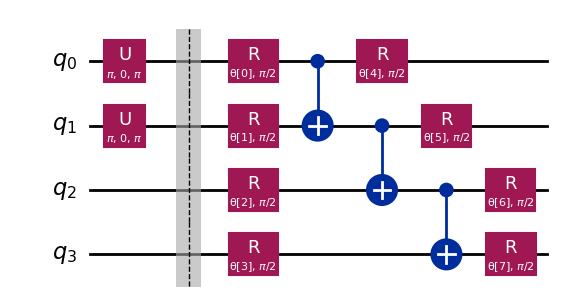

In [56]:
from qiskit.circuit.library import efficient_su2


hf_state = QuantumCircuit(n_qubits)

# Initialize to Hartree-Fock state
for i in range(n_electrons):
    hf_state.x(i)
hf_state.barrier()

ansatz = hf_state.compose(
    efficient_su2(
        num_qubits=n_qubits,
        su2_gates=["ry"],
        entanglement="linear",
        reps=1,
        skip_final_rotation_layer=False,
        insert_barriers=False,
    ),
    inplace=False,
)

ansatz.decompose().draw("mpl", idle_wires=False)

In [57]:
num_params = ansatz.num_parameters
x0 = np.zeros(num_params)  # np.ones(num_params) * np.pi/2
parameter_bound = [(-np.pi, np.pi) for _ in range(num_params)]
print("Number of ansatz parameters:", num_params)

Number of ansatz parameters: 8



------------------

## 2-3. Abstract and Ideal Setup - Running on Local Emulator

We first work in purely local mode with `StatevectorEstimator` so that the optimization logic is easy to inspect.

Later we will switch to the **Qiskit Pattern** view:
- abstract circuit / observable (Already done in Section 2-2),
- transpiled **ISA circuit**,
- layout-applied **ISA observable**,
- execution via `Estimator` or `Sampler`.
  
\*  (ISA = Instruction Set Architecture)

In this section, we ignore hardware constraints and use Qiskit’s `StatevectorEstimator`, which evaluates expectation values directly from the exact statevector for emulating an ideal, noise-free setting.

The function `estimate_energy_sv(theta)` emulates the procedure of estimating the energy of given ansatz parameter.  
It packages the ansatz, the observable `H2_ham`, and the current parameter values into a **primitive unified block (PUB)**, runs the estimator, and extracts the resulting energy expectation value.  
This is the quantity minimized by [`scipy.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html), which here uses the derivative-free **Powell** method.

Once the optimization terminates, `res.x` contains the optimized variational parameters and `res.fun` is the final VQE energy.  
We then compare this value against the exact ground-state energy obtained earlier by direct diagonalization.  
In this ideal statevector setting, the remaining discrepancy comes only from the expressive power of the ansatz and the behavior of the classical optimizer, not from sampling noise or hardware errors.

In [58]:
estimator_sv = StatevectorEstimator()

energy_history = []
param_history = []

def estimate_energy_sv(theta):
    pub = (ansatz, H2_ham, theta) # Primitive unified block (PUB) for StatevectorEstimator
    result = estimator_sv.run([pub]).result()
    energy = float(np.real(result[0].data.evs))
    param_history.append(np.array(theta, dtype=float))
    energy_history.append(energy)
    return energy

# def callback_store(xk):

res = minimize(
    estimate_energy_sv,
    x0=x0,
    method="cobyla",
    bounds=parameter_bound,
    options={
        "maxiter": 100,
        "disp": True,
    },
)

ideal_vqe_theta = np.array(res.x, dtype=float)
ideal_vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {ideal_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(ideal_vqe_energy-exact_gnd):.3e}")


Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 100   Least value of F = -1.13406417881105   Constraint violation = 0.0
The corresponding X is:
[-0.20676152  0.00833492  0.00951175  0.43044888 -0.00597163  3.14159265
 -0.01472733 -0.42736232]
The constraint value is:
[-2.93483113 -3.14992758 -3.15110441 -3.57204154 -3.13562102 -6.28318531
 -3.12686532 -2.71423033 -3.34835418 -3.13325773 -3.1320809  -2.71114377
 -3.14756429  0.         -3.15631998 -3.56895498]

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Final VQE electronic energy: -1.1340641788
Exact electronic energy:     -1.1372701657
Absolute error:              3.206e-03


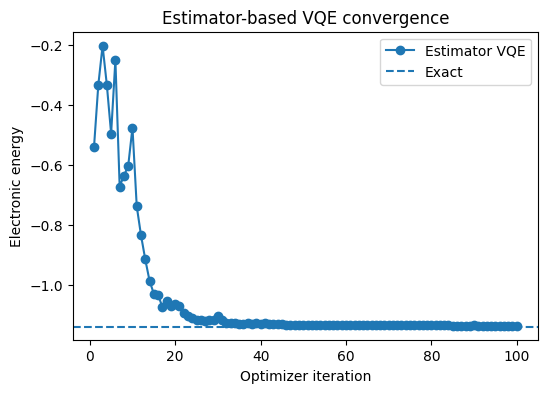

In [59]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history)+1), energy_history, marker="o", label="Estimator VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()


--------

## 2-4. Optimization: Mapping to ISA and Transpilation

The ansatz we constructed above is still an abstract circuit, but real hardware can only run circuits that match its supported basis gates and qubit connectivity. Qiskit therefore uses transpilation to convert the ansatz into an **ISA circuit**, which is the hardware-compatible form required for execution on IBM Quantum backends.

In the next cell, we first connect to the IBM Quantum service and select a real device with enough qubits for the demonstration.
Visit [https://quantum.cloud.ibm.com/computers](https://quantum.cloud.ibm.com/computers) for available backends.

In [60]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
# This may take a few seconds as it fetches the latest backend information.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
# Or by name:
backend = service.backend(backend_name)

print("Selected backend:", backend.name)
print("Backend gate set:", backend.operation_names)
print("Backend coupling map:", backend.coupling_map)
try: # Requires Graphviz to be installed and in PATH
    backend.coupling_map.draw(f"backend_{backend.name}_coupling_map.png")
    print(f"Coupling map diagram saved as backend_{backend.name}_coupling_map.png")
except Exception as e:
    pass

qiskit_runtime_service.__init__:WARNING:2026-03-30 02:20:09,117: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-30 02:20:09,119: Using instance: Solutions Notebooks premium fleet, plan: premium


Selected backend: ibm_torino
Backend gate set: ['delay', 'sx', 'reset', 'rz', 'id', 'measure', 'x', 'cz', 'if_else']
Backend coupling map: [[0, 1], [0, 15], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3], [4, 5], [4, 16], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [8, 7], [8, 9], [8, 17], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [12, 11], [12, 13], [12, 18], [13, 12], [13, 14], [14, 13], [15, 0], [15, 19], [16, 4], [16, 23], [17, 8], [17, 27], [18, 12], [18, 31], [19, 15], [19, 20], [20, 19], [20, 21], [21, 20], [21, 22], [21, 34], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 35], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 36], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 37], [34, 21], [34, 40], [35, 25], [35, 44], [36, 29], [36, 48], [37, 33], [37, 52], [38, 39], [38, 53], [39, 38], [39, 40], [40, 34], [40, 39], [40,

We then generate a preset pass manager with ([`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)), including layout selection, routing, basis-gate translation, and circuit optimization.
This generates a preset [`PassManager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.PassManager), which manages a set of Passes and their schedule during transpilation.

Here we use `optimization_level=3` to request the heaviest built-in optimization level, and `seed_transpiler=1234` to make the stochastic parts of transpilation reproducible.

In [61]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=1234,
)
print("Pass manager stages:", pm.stages)
try: # Requires Graphviz to be installed and in PATH
    pm.draw(f"pass_manager_{backend.name}.png")
    print(f"Pass manager diagram saved as pass_manager_{backend.name}.png")
except Exception as e:
    pass

Pass manager stages: ('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')


After transpilation, the circuit may not use the original logical qubit ordering, because the transpiler can choose a new layout to better match the hardware.  
For that reason, the Hamiltonian must also be updated to the same layout.
Qiskit’s `SparsePauliOp.apply_layout(...)` performs this step, ensuring that the observable is aligned with the transpiled ansatz before expectation values are evaluated. 

Finally, we inspect a few basic properties of the resulting ISA circuit, such as its depth, total size, operation counts, and final qubit layout.  

ISA Hamiltonian:
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYIIIYXXIIIIIIIIIIII', 'IIIIIIII

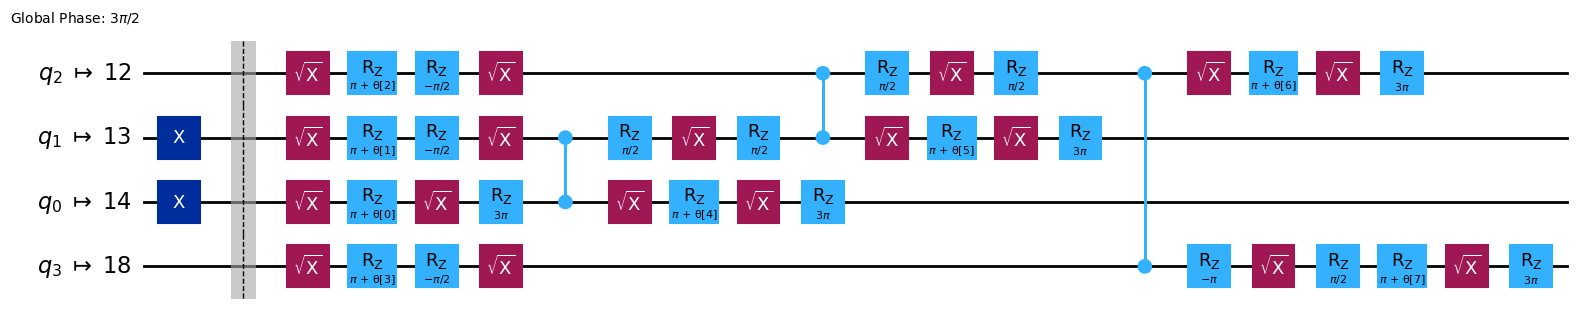

In [62]:
# Transpilation of a circuit to match the target backend's constraints (ISA)
isa_ansatz = pm.run(ansatz) 

# Transform the Hamiltonian to match the qubit layout of the transpiled circuit
isa_hamiltonian = H2_ham.apply_layout(isa_ansatz.layout)

print("ISA Hamiltonian:")
print(isa_hamiltonian)

print("ISA depth:", isa_ansatz.depth())
print("ISA size:", isa_ansatz.size())
print("ISA operations:", isa_ansatz.count_ops())
print("Layout:", '\n\t'.join(repr(isa_ansatz.layout.initial_layout).splitlines()[:5]), "\n\t...\n\t})")
print("Transpiled Circuit:")
isa_ansatz.draw("mpl", idle_wires=False)


-------

## 2-5. Execution and Postprocessing

After building the ansatz and compiling it into an ISA circuit, the next step is to *execute* expectation-value evaluations and turn the raw results into quantities that are useful for chemistry.
In Qiskit's runtime workflow, this usually means sending `(circuit, observable, parameter values)` tuples (i.e. **Primitive Unified Block, PUB**) to an `Estimator`, then postprocessing the returned expectation values to estimate energies, compare different settings, and monitor convergence.

The IBM Runtime execution modes are:

- **Job mode**: *A single run* of a primitive. This is the simplest option, and it is well suited for one-off evaluations such as checking the energy at a specific parameter point.
- **Batch mode**: *Parallel or grouped runs* of primitives. This is useful when several independent workloads should be submitted together, for example when comparing different error-mitigation settings on the same circuit and observable.
- **Session mode**: *Sequential runs* of primitives with reduced latency between calls. This is the most natural mode for hybrid algorithms such as VQE, where each optimizer step requests a new expectation-value evaluation based on the previous result. Session mode is not available for open-access users.

In this VQE tutorial, these modes are used for the following purposes:

- **Job mode**: a single-point energy evaluation.
- **Batch mode**: comparison of several [error-mitigation settings](https://quantum.cloud.ibm.com/docs/en/guides/configure-error-mitigation).
- **Session mode**: the actual iterative VQE loop, where parameters are updated repeatedly.

You can also browse submitted workloads online from the IBM Quantum Platform:
[https://quantum.cloud.ibm.com/workloads](https://quantum.cloud.ibm.com/workloads)

In [63]:
from qiskit_ibm_runtime import (
    EstimatorV2 as Estimator,
    Session,
    Batch,
)

default_shots = 10000

# 1) Job mode: one single energy evaluation
estimator = Estimator(mode=backend, options={"default_shots": default_shots})
pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
job = estimator.run([pub])
print("job status:", job.status())  # Asynchronously check job status in real-time.
result = job.result() # Wait for job to complete and get results
print("job status (after wait):", job.status())
estimated_energy = float(result[0].data.evs[0])
print(f"Single run estimated energy Error: {abs(estimated_energy - exact_gnd):.3f}")

job status: QUEUED
job status (after wait): DONE
Single run estimated energy Error: 0.102


In Batch mode, we compare the gradual application of various error mitigation techniques.

`resilience_level = 0`: No mitigation

`resilience_level = 1`: Twirled Readout Error eXtinction (TREX) / measurement mitigation + measurement twirling

`resilience_level = 2`: level 1 + gate twirling + Zero-Noise Extrapolation (ZNE)

In [64]:
# 2) Batch mode: compare several mitigation levels in one grouped submission
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the comparision between different mitigation levels.
'''
with Batch(backend=backend, max_time="5m") as batch:
    pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
    # submit separate runs with different option objects or different PUB sets
    batch = [
        Estimator(mode=batch, options={"resilience_level": 0, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 1, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 2, "default_shots": default_shots}).run([pub])
    ]
results = [est.result() for est in batch]
estimated_energies = [float(res[0].data.evs[0]) for res in results]
print(f"Batch run estimated energy Errors: {[abs(energy - exact_gnd) for energy in estimated_energies]}")
'''

''

''

Expected Result:
```
Batch run estimated energy Errors: [0.1417889042648406, 0.06748944597138373, 0.052310730542233896]
```


In [65]:
# 3) Session mode: best for iterative VQE
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the full VQE optimization on a real backend.
'''
energy_history_session = []
param_history_session = []

def estimate_energy_session(theta, ansatz, hamiltonian, session):
    estimator = Estimator(mode=session, options={"resilience_level": 1, "default_shots": default_shots})
    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run([pub]).result()
    evs = float(result[0].data.evs[0])
    energy_history_session.append(evs)
    param_history_session.append(theta)
    return evs

with Session(backend=backend, max_time="10m") as session:
    res = minimize(
        estimate_energy_session,
        ideal_vqe_theta,
        args=(isa_ansatz, isa_hamiltonian, session),
        method="POWELL",
        options={"maxiter": 10, "disp": True},
    )

session_vqe_theta = np.array(res.x, dtype=float)
session_vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {session_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(session_vqe_energy-exact_gnd):.3e}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history_session)+1), energy_history_session, marker="o", label="Real-Backend VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()

'''

''

''


-----------

## 2-6. SQD-style ground-state estimation from samples

So far, the VQE part of the notebook estimated the ground-state energy through the
expectation value
$$
    E(\boldsymbol{\theta})=\langle \psi(\boldsymbol{\theta})|H|\psi(\boldsymbol{\theta})\rangle.
$$

We now add a second viewpoint, inspired by **Sample-based Quantum Diagonalization (SQD)**.

![sqd.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/sqd.png)

The key idea is different from standard VQE postprocessing:

1. prepare a trial state $|\psi(\boldsymbol{\theta})\rangle$,
2. sample computational-basis bitstrings from that state,
3. use the observed bitstrings to define a sampled subspace $S$ (additionally include configuration recovery),
4. project the Hamiltonian onto that subspace,
5. diagonalize the projected matrix classically.

If the measured samples already contain the dominant support of the true ground state,
then the projected Hamiltonian can yield a better energy estimate, less prone to noise.

If the sampled bitstrings are
$$
    S=\{\boldsymbol{x}_1,\boldsymbol{x}_2,\cdots,\boldsymbol{x}_k\},
$$
then we form the projected Hamiltonian
$$
    H_{\mathrm{sub}} = P_{\mathrm{sub}}^\dagger H P_{\mathrm{sub}},
$$
where $P_{\mathrm{sub}}$ embeds the sampled computational-basis subspace into the full
Hilbert space. We then take the smallest eigenvalue of $H_{\mathrm{sub}}$ as the
SQD-style estimate:
$$
    E_{\mathrm{SQD}}(\boldsymbol{\theta}) = \min(\mathrm{diag}(H_{\mathrm{sub}})).
$$

We first test this projected-energy routine at the optimized parameters found from the
ideal Estimator-based VQE run in the next cell.


In [66]:
def sample_bitstrings(circuit, theta, sampler, shots):
    circuit_measured = circuit.copy()
    circuit_measured.measure_all()
    job = sampler.run([(circuit_measured, theta)], shots=shots)
    sampled_bitstrings = list(job.result()[0].data.meas.get_bitstrings())
    return sampled_bitstrings

def sqd_energy_from_samples(samples, hamiltonian_matrix):
    """Project the full Hamiltonian onto the sampled computational-basis subspace."""
    samples = set(samples) # Remove duplicates
    selected = sorted(
        {int(bitstr.replace(" ", ""), 2) for bitstr in samples}
    )
    if len(selected) == 0:
        raise ValueError("No sampled bitstrings were provided.")
    proj = hamiltonian_matrix[np.ix_(selected, selected)]
    evals = np.linalg.eigvalsh(proj)
    return float(np.min(evals))

# quick test at the optimized parameters
sampler = StatevectorSampler()
samples_test = sample_bitstrings(ansatz, ideal_vqe_theta, sampler, shots=1000)
sqd_energy_test = sqd_energy_from_samples(samples_test, H2_matrix)

print(f"SQD-style electronic energy at optimized parameters: {sqd_energy_test:.10f}")
print(f"Exact electronic energy:                           {exact_gnd:.10f}")
print(f"Sampled basis states in subspace: {sorted(set(samples_test))}")
print(f"Number of sampled basis states in subspace:       {len(set(samples_test))}")

SQD-style electronic energy at optimized parameters: -1.1372701657
Exact electronic energy:                           -1.1372701657
Sampled basis states in subspace: ['0011', '0100', '1100']
Number of sampled basis states in subspace:       3


### Advanced: Scalable matrix projection
The function `sqd_energy_from_samples` projected the Hamiltonian by first building the ($2^n\times 2^n$) **full matrix**
and then slicing out the sampled subspace. That is fine for a 4-qubit toy model,
but it is not the scalable idea behind SQD.
To study the scalable version, see [advanced-2_ScalableSubspaceSampling.ipynb](#advanced-2-scalable-subspace-hamiltonian-generation-from-pauli-terms-and-samples).


### Advanced: Configuration recovery

In realistic sampling with noisy quantum computing, the measured bitstrings are not always perfectly aligned with the
physical symmetry sector of interest.
For example, even when the target wavefunction should preserve the correct particle number and often spin sector, noise can produce samples whose occupation pattern is slightly inconsistent with those constraints.

For example, even if we deal with H2 molecule, containing 2 electrons, we can sample configurations with different number of electrons under the noisy condition:
$$
    |0000\rangle, |1000\rangle, |0111\rangle ...
$$


**Configuration recovery** is a classical postprocessing step that attempts to repair such samples before building the sampled subspace.

Conceptually, the recovery loop works as follows:

1. start from the measured bitstrings,
2. estimate average orbital occupations from the current SQD solution,
3. modify or reweight bitstrings so they better satisfy the target symmetry constraints,
4. rebuild the sampled subspace from the recovered configurations,
5. diagonalize again and iterate if needed.




-------

### Comparison of energy estimation with Estimator vs SQD under a backend-like noise model

Here we compare two energy estimation routes using the same fixed optimized parameters obtained earlier, without re-running the classical optimization.

Instead of running the actual backend, we construct a **backend-like noise model** with `NoiseModel.from_backend()` and use it in local simulation so that the measurement results include realistic gate and readout errors.

- **Estimator** evaluates the expectation value
  $$
  E(\theta)=\langle \psi(\theta)|H|\psi(\theta)\rangle,
  $$
  for the fixed optimized parameters. In the ideal statevector setting this value is essentially deterministic, but under noisy shot-based execution the estimated energy can fluctuate and deviate from the exact value.

- **SQD** first samples computational-basis bitstrings from the noisy circuit output, constructs the projected Hamiltonian on the sampled subspace, and then diagonalizes that reduced matrix. Its quality therefore depends not only on the shot count, but also on how noise changes the sampled support.

To see these effects more clearly, we increase the shot count in small steps of 50.
At very small shot counts, the sampled subspace may miss important basis states, so the SQD estimate can fluctuate noticeably. As the number of shots increases, the sampled support typically becomes richer.

The plots below show:

1. the energy comparison between **Estimator** and **SQD** at the same optimized parameters under noisy simulation, and  
2. how the **sampled subspace dimension** grows with the shot budget.

For more discussion of the comparision, visit [here](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/sqd-overview#5-sqd-vs-vqe).

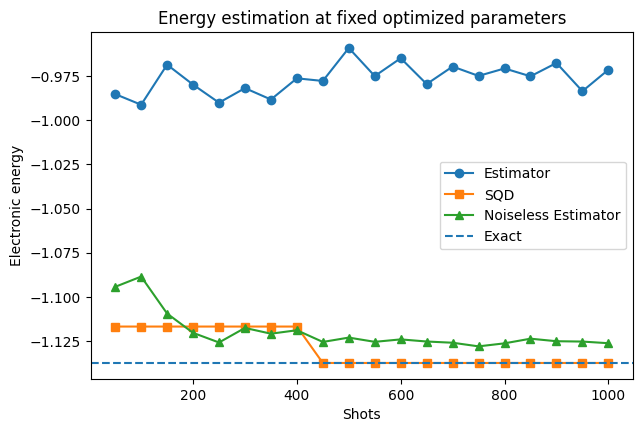

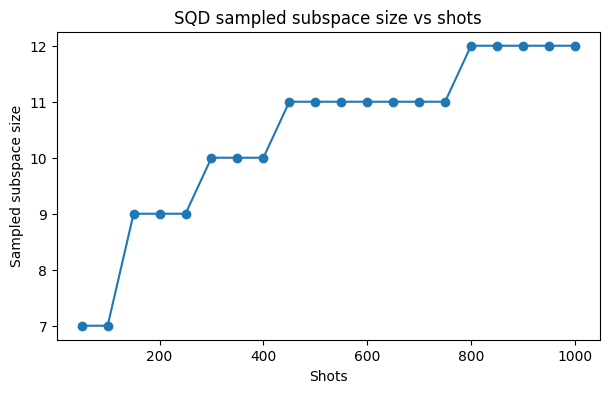

shots= 50 | Estimator=-0.9852919648 | SQD=-1.1166843800 | Noiseless=-1.0942301256 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=4.304e-02 | dim=7
shots=100 | Estimator=-0.9913061488 | SQD=-1.1166843800 | Noiseless=-1.0884416624 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=4.883e-02 | dim=7
shots=150 | Estimator=-0.9686554791 | SQD=-1.1166843800 | Noiseless=-1.1093375256 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=2.793e-02 | dim=9
shots=200 | Estimator=-0.9799486172 | SQD=-1.1166843800 | Noiseless=-1.1202386792 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.703e-02 | dim=9
shots=250 | Estimator=-0.9901506132 | SQD=-1.1166843800 | Noiseless=-1.1256916386 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.158e-02 | dim=9
shots=300 | Estimator=-0.9819165517 | SQD=-1.1166843800 | Noiseless=-1.1174610820 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.981e-02 | dim=10
shots=350 | Estimator=-0.9883516226 | SQD=-1.1166843800 | Noiseless=-1.1207169166 | |SQD-Exact|=2.059e-02 | |Noiseless-Exact|=1.655e-02

In [67]:
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.primitives import Estimator as AerEstimator


max_shots = 1000
step_shots = 50
shot_grid = list(range(step_shots, max_shots + 1, step_shots))

# `backend` should be a backend object chosen earlier in the notebook.
noise_model = NoiseModel.from_backend(backend)

# Noisy sampler for obtaining raw bitstrings.
noisy_sampler = AerSampler(
    seed=1234,
    options={
        "backend_options": {
            "noise_model": noise_model,
            "method": "density_matrix",
        }
    },
)

# Finite-shot noisy estimator.
noisy_estimator = AerEstimator(
    approximation=False,
    backend_options={
        "noise_model": noise_model,
        "method": "density_matrix",
    },
    run_options={
        "seed": 1234,
    },
)

# Finite-shot noiseless estimator.
noiseless_estimator = AerEstimator(
    approximation=False,
    backend_options={
        "noise_model": None,
        "method": "density_matrix",
    },
    run_options={
        "seed": 1234,
    },
)

# Draw one maximum-shot sample record once, then use its prefixes for SQD.
all_samples = sample_bitstrings(ansatz, ideal_vqe_theta, noisy_sampler, shots=max_shots)

comparison = []

for shots in shot_grid:
    prefix_samples = all_samples[:shots]
    sqd_energy = sqd_energy_from_samples(prefix_samples, H2_matrix)

    est_result = noisy_estimator.run([ansatz], [H2_ham], [ideal_vqe_theta], shots=shots).result()
    estimator_energy = float(np.real(est_result.values[0]))

    noiseless_est_result = noiseless_estimator.run([ansatz], [H2_ham], [ideal_vqe_theta], shots=shots).result()
    noiseless_energy = float(np.real(noiseless_est_result.values[0]))

    comparison.append((shots, estimator_energy, sqd_energy, noiseless_energy, len(set(prefix_samples))))

shots = [x[0] for x in comparison]
estimator_energies = [x[1] for x in comparison]
sqd_energies = [x[2] for x in comparison]
noiseless_energies = [x[3] for x in comparison]
subspace_sizes = [x[4] for x in comparison]

plt.figure(figsize=(7, 4.5))
plt.plot(shots, estimator_energies, marker="o", label="Estimator")
plt.plot(shots, sqd_energies, marker="s", label="SQD")
plt.plot(shots, noiseless_energies, marker="^", label="Noiseless Estimator")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Shots")
plt.ylabel("Electronic energy")
plt.title("Energy estimation at fixed optimized parameters")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4.0))
plt.plot(shots, subspace_sizes, marker="o")
plt.xlabel("Shots")
plt.ylabel("Sampled subspace size")
plt.title("SQD sampled subspace size vs shots")
plt.show()

for shots_i, e_est, e_sqd, e_noiseless, dim in comparison:
    print(
        f"shots={shots_i:3d} | "
        f"Estimator={e_est:.10f} | "
        f"SQD={e_sqd:.10f} | "
        f"Noiseless={e_noiseless:.10f} | "
        f"|SQD-Exact|={abs(e_sqd - exact_gnd):.3e} | "
        f"|Noiseless-Exact|={abs(e_noiseless - exact_gnd):.3e} | "
        f"dim={dim}"
    )


------

## Conclusion

In this tutorial, we used the `H2` Hamiltonian as a minimal but complete example of quantum ground-state estimation. We started from the explicit qubit Hamiltonian, obtained the exact classical reference by diagonalization, and then followed the VQE workflow from ansatz construction to primitive-based execution and optimization.
We also compared two different estimation strategies: direct expectation estimation with the Estimator primitive, and an SQD-style sampled-subspace reconstruction.

------

# Advanced-1. Exploring Precalculated Hamiltonians
<a id="advanced-1-exploring-precalculated-hamiltonians"></a>

_Source: `advanced-1_PrecalculatedHamiltonians.ipynb`_

In this chapter, we are going to show that the **classical exact solving** quickly becomes the bottleneck.

1. load a library of **precomputed qubit Hamiltonians**,  
2. inspect how the problem size grows with the molecular system,  
3. and compare that growth with the cost of **exact diagonalization**.

In [68]:
from utils import load_sparse_pauli_ops_from_pickle
import numpy as np
import matplotlib.pyplot as plt
from time import time

## A1-1. Load the Precomputed Hamiltonians

![hydrogen_chain.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/hydrogen_chain.png)

We load a collection of precalculated qubit Hamiltonians for linear hydrogen chains.
Each entry is already stored as a `SparsePauliOp`, so we can immediately inspect:

- the number of qubits,
- the number of Pauli terms,
- and a concrete small example such as `H2`.

This separates **Hamiltonian generation** from **Hamiltonian analysis**.


In [69]:
loaded_ham = load_sparse_pauli_ops_from_pickle("linear_h_chains_jw.json")
available = sorted(loaded_ham.keys(), key=lambda name: int(name[1:]))

print("Available molecules:", available)

example = "H2"
ham = loaded_ham[example]
print(f"\n{example}:")
print(f"  n_qubits = {ham.num_qubits}")
print(f"  n_terms  = {len(ham)}")
print(ham)


Available molecules: ['H2', 'H3', 'H4', 'H5', 'H6', 'H7']

H2:
  n_qubits = 4
  n_terms  = 15
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'YXXY', 'XXYY', 'YYXX', 'XYYX', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
 -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
 -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
  0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j])


## A1-2. Exact Diagonalization as a Reference

For small systems, we can still convert the Pauli Hamiltonian into a dense matrix and compute
its exact spectrum with `numpy.linalg.eigh`.

That is useful as a **reference calculation**, but it is not scalable:
if the Hamiltonian acts on $n$ qubits, then the dense matrix has dimension
$$
2^n \times 2^n.
$$

So in this notebook we use exact diagonalization only to illustrate the scaling trend.
By default we stop at `H6` to keep the runtime lightweight.


In [70]:
def exact_ground_state_energy(hamiltonian):
    mat = np.array(hamiltonian)
    evals, _ = np.linalg.eigh(mat)
    return float(np.min(evals)), mat.shape[0]

max_chain_to_diagonalize = 7
results = []

for name in available:
    n_chain = int(name[1:])
    ham = loaded_ham[name]

    entry = {
        "name": name,
        "n_chain": n_chain,
        "n_qubits": ham.num_qubits,
        "n_terms": len(ham),
    }

    if n_chain <= max_chain_to_diagonalize:
        print(f"Diagonalizing {name} ...")
        t0 = time()
        energy, dim = exact_ground_state_energy(ham)
        elapsed = time() - t0

        entry["dimension"] = dim
        entry["ground_energy"] = energy
        entry["solve_time"] = elapsed

        print(f"  n_qubits = {ham.num_qubits}")
        print(f"  n_terms  = {len(ham)}")
        print(f"  matrix dimension = {dim}")
        print(f"  exact ground-state energy = {energy:.10f}")
        print(f"  wall time = {elapsed:.3f} s\n")
    else:
        entry["dimension"] = 2 ** ham.num_qubits
        entry["ground_energy"] = None
        entry["solve_time"] = None
        print(f"Skipping exact diagonalization for {name} to avoid a long runtime.\n")

    results.append(entry)


Diagonalizing H2 ...
  n_qubits = 4
  n_terms  = 15
  matrix dimension = 16
  exact ground-state energy = -1.1372701747
  wall time = 0.000 s

Diagonalizing H3 ...
  n_qubits = 6
  n_terms  = 62
  matrix dimension = 64
  exact ground-state energy = -1.5269470051
  wall time = 0.003 s

Diagonalizing H4 ...
  n_qubits = 8
  n_terms  = 185
  matrix dimension = 256
  exact ground-state energy = -2.1397996447
  wall time = 0.114 s

Diagonalizing H5 ...
  n_qubits = 10
  n_terms  = 444
  matrix dimension = 1024
  exact ground-state energy = -2.5582083208
  wall time = 0.956 s

Diagonalizing H6 ...


KeyboardInterrupt: 

## A1-3. Visualize the Growth

We now compare several quantities as the chain length increases:

- number of qubits,
- number of Pauli terms,
- Hilbert-space dimension $2^n$,
- and exact diagonalization time for the systems we actually solved.

The first three are structural properties of the Hamiltonian.
The last one reflects the classical cost of solving it exactly.


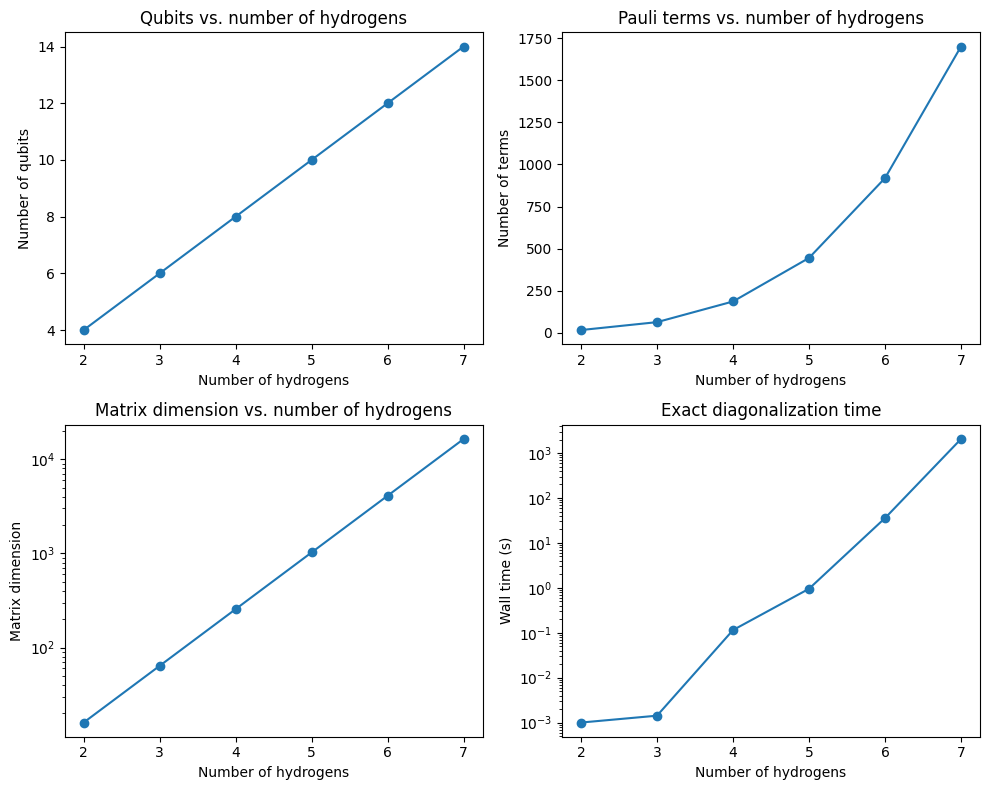

In [ ]:
n_chain_list = [r["n_chain"] for r in results]
n_qubits_list = [r["n_qubits"] for r in results]
n_terms_list = [r["n_terms"] for r in results]
dimensions_list = [r["dimension"] for r in results]

timed_results = [r for r in results if r["solve_time"] is not None]
timed_n_chain = [r["n_chain"] for r in timed_results]
timed_solve_time = [r["solve_time"] for r in timed_results]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(n_chain_list, n_qubits_list, marker="o")
axs[0, 0].set_title("Qubits vs. number of hydrogens")
axs[0, 0].set_xlabel("Number of hydrogens")
axs[0, 0].set_ylabel("Number of qubits")

axs[0, 1].plot(n_chain_list, n_terms_list, marker="o")
axs[0, 1].set_title("Pauli terms vs. number of hydrogens")
axs[0, 1].set_xlabel("Number of hydrogens")
axs[0, 1].set_ylabel("Number of terms")

axs[1, 0].plot(n_chain_list, dimensions_list, marker="o")
axs[1, 0].set_title("Matrix dimension vs. number of hydrogens")
axs[1, 0].set_xlabel("Number of hydrogens")
axs[1, 0].set_ylabel("Matrix dimension")
axs[1, 0].set_yscale("log")

axs[1, 1].plot(timed_n_chain, timed_solve_time, marker="o")
axs[1, 1].set_title("Exact diagonalization time")
axs[1, 1].set_xlabel("Number of hydrogens")
axs[1, 1].set_ylabel("Wall time (s)")
axs[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()


## A1-4. Interpretation

The main message is the contrast between two kinds of cost:

1. **storing the Hamiltonian as a Pauli sum**, and  
2. **solving the Hamiltonian exactly as a dense matrix problem**.

Even when the Hamiltonian is already available in a compact Pauli representation,
the full Hilbert-space dimension still grows exponentially with the number of qubits.
That is why exact diagonalization becomes impractical much sooner than simple Hamiltonian inspection.

This is precisely the regime where variational methods or sampled-subspace methods become useful:
they try to extract low-energy information **without** solving the full $2^n$-dimensional problem.


------

# Advanced-2. Scalable Subspace Hamiltonian Generation from Pauli Terms and Samples
<a id="advanced-2-scalable-subspace-hamiltonian-generation-from-pauli-terms-and-samples"></a>

_Source: `advanced-2_ScalableSubspaceSampling.ipynb`_

This notebook focuses on one specific SQD ingredient:

1. Start from a qubit Hamiltonian written as a **sparse Pauli sum**  
   $$
   H = \sum_\ell c_\ell P_\ell.
   $$

2. Collect **computational-basis samples**  
   $$
   S = \{x_1, x_2, \dots, x_k\}.
   $$

3. Construct the sampled subspace Hamiltonian
   $$
   H_{\mathrm{sub}} = P_S\, H\, P_S
   $$
   **without** materializing the full $2^n \times 2^n$ $H$ matrix.

For a small toy model we will still compare against the full matrix once, only as a validation check.
Instead, we should construct the projected matrix **directly from the Pauli
Hamiltonian and the sampled bitstrings**.

Suppose the Hamiltonian is written as
$$
H = \sum_{\ell} c_\ell P_\ell,
$$
where each $P_\ell$ is a Pauli string such as `IZZI`, `XXYY`, and so on.
If the sampled support is
$$
S = \{x_1, x_2, \dots, x_k\},
$$
then the SQD projected Hamiltonian is the $k\times k$ matrix
$$
(H_{\mathrm{sub}})_{ab}
= \langle x_a | H | x_b \rangle
= \sum_{\ell} c_\ell \langle x_a | P_\ell | x_b \rangle.
$$

The key point is that a Pauli string acts very simply on a computational-basis state:

- `I` leaves the bit unchanged,
- `Z` leaves the bit unchanged and contributes a sign,
- `X` flips the bit,
- `Y` flips the bit and contributes a phase.

So for a basis bitstring $x$,
$$
P_\ell |x\rangle = \omega_\ell(x)\, |x \oplus f_\ell\rangle,
$$
where $f_\ell$ is the flip mask determined by the `X`/`Y` locations, and
$\omega_\ell(x)$ is the phase/sign accumulated from the local Pauli actions.

This immediately gives
$$
\langle x_a | P_\ell | x_b \rangle
=
\omega_\ell(x_b)\,\delta_{x_a,\; x_b \oplus f_\ell}.
$$

That means we never need the full $2^n \times 2^n$ matrix:

- `I`/`Z`-only terms do **not** flip bitstrings, so they contribute to
  **diagonal elements** of the sampled subspace matrix.
- Terms containing `X` or `Y` create **transitions** between sampled bitstrings.
  They contribute only when the flipped bitstring is also present in the sampled support.

This is the scalable SQD construction: iterate over sampled basis states and Pauli
terms, and fill only the matrix elements that are actually connected inside the
sampled subspace.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import excitation_preserving
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector


## A2-1. Hamiltonian Definition

We use the same 4-qubit qubit Hamiltonian for $\mathrm{H}_2$ as in the earlier tutorial:
$$
H=\sum_j c_j P_j,
\qquad
P_j \in \{I,X,Y,Z\}^{\otimes 4}.
$$

This is still small enough to validate against the full matrix, but the construction we implement below is **not tied** to the small-system regime.


In [ ]:
H2_ham = SparsePauliOp(
    [
        'IIII', 'IIIZ', 'IIZI', 'IZII',
        'ZIII', 'IIZZ', 'YXXY', 'XXYY',
        'YYXX', 'XYYX', 'IZIZ', 'ZIIZ',
        'IZZI', 'ZIZI', 'ZZII'
    ],
    coeffs=[
        -0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
        -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
        -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
         0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j
    ]
)

n_qubits = H2_ham.num_qubits
print("Number of qubits:", n_qubits)
print("Number of Pauli terms:", len(H2_ham))
print(H2_ham)

full_H_matrix = H2_ham.to_matrix() # This is not scalable.

Number of qubits: 4
Number of Pauli terms: 15
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'YXXY', 'XXYY', 'YYXX', 'XYYX', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
 -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
 -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
  0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j])


## A2-2. Action of a Pauli String on a Computational-Basis State

Let $x\in\{0,1\}^n$ be a computational-basis bitstring.  
For each qubit, the local Pauli action is:

- $I\ket{b} = \ket{b}$,
- $Z\ket{b} = (-1)^b\ket{b}$,
- $X\ket{b} = \ket{b\oplus 1}$,
- $Y\ket{b} = i(-1)^b\ket{b\oplus 1}$.

So for a full Pauli string $P_\ell$ we have
$$
P_\ell \ket{x}
=
\omega_\ell(x)\,
\ket{x \oplus f_\ell},
$$
where:

- $f_\ell$ is the **flip mask** determined by the positions of `X` and `Y`,
- $\omega_\ell(x)$ is the accumulated sign/phase.

This immediately implies
$$
\langle x_a | P_\ell | x_b \rangle
=
\omega_\ell(x_b)\,\delta_{x_a,\;x_b\oplus f_\ell}.
$$

That is the key rule behind direct subspace construction.

### Diagonal vs transition terms

This rule also explains the difference between two classes of Pauli terms:

1. **Diagonal terms**  
   If a Pauli string contains only `I` and `Z`, then it does not flip the bitstring.
   It contributes only to
   $$
   \langle x|P_\ell|x\rangle.
   $$

2. **Transition terms**  
   If a Pauli string contains `X` or `Y`, then it flips one or more bits.
   It contributes only between connected sampled states
   $$
   x_b \longrightarrow x_b \oplus f_\ell.
   $$

So the sampled subspace Hamiltonian can be filled by checking whether the Pauli-induced destination bitstring is also contained in the sampled support.


In [ ]:
def pauli_action_on_bitstring(pauli_label, bitstr):
    """Return (output_bitstring, phase) for P|bitstr>.

    Convention:
    - `bitstr` is the displayed computational-basis bitstring, e.g. '1010'.
    - `pauli_label` is the displayed Qiskit Pauli label, e.g. 'IZXY'.
    - We apply both left-to-right in the same displayed order.
    """
    out = list(bitstr)
    phase = 1.0 + 0.0j

    for i, (p, b) in enumerate(zip(pauli_label, bitstr)):
        if p == "I":
            continue
        elif p == "Z":
            if b == "1":
                phase *= -1
        elif p == "X":
            out[i] = "0" if b == "1" else "1"
        elif p == "Y":
            phase *= 1j if b == "0" else -1j
            out[i] = "0" if b == "1" else "1"
        else:
            raise ValueError(f"Unexpected Pauli character: {p}")

    return "".join(out), phase


Let us inspect a few individual examples.


In [ ]:
examples = [
    ("IIZZ", "0101"),
    ("XXYY", "0101"),
    ("YXXY", "1010"),
    ("ZZII", "1110"),
]

for label, bitstr in examples:
    out, phase = pauli_action_on_bitstring(label, bitstr)
    print(f"{label} |{bitstr}> = ({phase}) |{out}>")


IIZZ |0101> = ((-1+0j)) |0101>
XXYY |0101> = ((1-0j)) |1010>
YXXY |1010> = ((1+0j)) |0101>
ZZII |1110> = ((1-0j)) |1110>


## A2-3. Direct Construction of the Sampled Subspace Hamiltonian

Suppose the sampled support is
$$
S=\{x_1,\dots,x_k\}.
$$

Then the projected matrix elements are
$$
(H_{\mathrm{sub}})_{ab}
=
\langle x_a|H|x_b\rangle
=
\sum_\ell c_\ell \langle x_a|P_\ell|x_b\rangle.
$$

The direct algorithm is therefore:

1. keep an ordered list of sampled bitstrings,
2. create a dictionary from bitstring to row/column index,
3. for each Pauli term $c_\ell P_\ell$,
4. for each sampled basis state $x_b$,
5. compute the destination bitstring $x_b \oplus f_\ell$ and phase $\omega_\ell(x_b)$,
6. add $c_\ell \omega_\ell(x_b)$ to the corresponding matrix element **only if** the destination bitstring is also in the sampled support.

This has cost roughly
$$
O\!\left(|S| \times N_{\mathrm{Pauli}}\right),
$$
instead of full-matrix construction.


In [ ]:
def build_subspace_hamiltonian_from_samples(hamiltonian, samples, *, return_contributions=False):
    """Build H_sub directly from SparsePauliOp + sampled support.

    Parameters
    ----------
    hamiltonian : SparsePauliOp
        Qubit Hamiltonian written as a Pauli sum.
    samples : iterable[str]
        Sampled computational-basis bitstrings.
    return_contributions : bool
        If True, also return a simple summary of diagonal/transition contributions.

    Returns
    -------
    H_sub : np.ndarray
        Projected Hamiltonian on the sampled support.
    basis : list[str]
        Ordered sampled basis states.
    contribution_log : list[dict], optional
        A lightweight term-by-term summary, useful for teaching/debugging.
    """
    basis = sorted(set(bitstr.replace(" ", "") for bitstr in samples))
    if len(basis) == 0:
        raise ValueError("No sampled bitstrings were provided.")

    index = {b: i for i, b in enumerate(basis)}
    dim = len(basis)
    H_sub = np.zeros((dim, dim), dtype=complex)

    contribution_log = []

    for pauli_label, coeff in zip(hamiltonian.paulis.to_labels(), hamiltonian.coeffs):
        has_transition = any(ch in "XY" for ch in pauli_label)
        hits = 0

        for ket in basis:
            bra, phase = pauli_action_on_bitstring(pauli_label, ket)
            i = index.get(bra)
            if i is not None:
                j = index[ket]
                H_sub[i, j] += coeff * phase
                hits += 1

        if return_contributions:
            contribution_log.append(
                {
                    "label": pauli_label,
                    "coeff": coeff,
                    "type": "transition" if has_transition else "diagonal",
                    "hits_in_support": hits,
                }
            )

    # Clean up tiny non-Hermitian numerical noise if present.
    H_sub = 0.5 * (H_sub + H_sub.conj().T)

    if return_contributions:
        return H_sub, basis, contribution_log
    return H_sub, basis


def sqd_energy_from_samples(samples, hamiltonian):
    """Lowest eigenvalue of the sampled subspace Hamiltonian."""
    H_sub, basis = build_subspace_hamiltonian_from_samples(hamiltonian, samples)
    evals = np.linalg.eigvalsh(H_sub)
    return float(np.min(np.real(evals))), basis, H_sub


## A2-4. A Small Sampled Support by Hand

Before sampling from a circuit, let us manually choose a small support and inspect the resulting projected matrix.


In [ ]:
manual_samples = {
    "0011",
    "0110",
    "1001",
    "1100",
}

H_sub_manual, basis_manual, log_manual = build_subspace_hamiltonian_from_samples(
    H2_ham,
    manual_samples,
    return_contributions=True,
)

print("Sampled basis states:", basis_manual)
print("Projected subspace shape:", H_sub_manual.shape)
with np.printoptions(precision=3, suppress=True):
    print(H_sub_manual.real)


Sampled basis states: ['0011', '0110', '1001', '1100']
Projected subspace shape: (4, 4)
[[-1.117  0.     0.     0.181]
 [ 0.    -0.351 -0.181  0.   ]
 [ 0.    -0.181 -0.351  0.   ]
 [ 0.181  0.     0.     0.459]]
